In [26]:
# Import libraries

import json
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

import shap

In [27]:
DATA_PATH = Path("../data/processed/crop_recommendation_clean.csv")
MODEL_PATH = Path("../models/crop_model_tuned.joblib")

df = pd.read_csv(DATA_PATH)
model = joblib.load(MODEL_PATH)

df.head()

C:\Users\User\OneDrive\Desktop\Projects\cropwise-ai\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\User\OneDrive\Desktop\Projects\cropwise-ai\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\User\OneDrive\Desktop\Projects\cropwise-ai\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to

,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [28]:
target_col ="label"

X = df.drop(columns=target_col)
y = df[target_col]

feature_names = X.columns.tolist()

feature_names

['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

In [30]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](22,)","['apple','banana','blackgram',...,'pomegranate','rice','watermelon']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['n','p','k',...,'humidity','ph','rainfall']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [31]:
final_model = model.named_steps["model"]

final_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the r

In [32]:
importances = final_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df

,feature,importance
0,rainfall,0.235417
1,humidity,0.214631
2,k,0.174967
3,p,0.151864
4,n,0.103185
5,temperature,0.069130
6,ph,0.050805


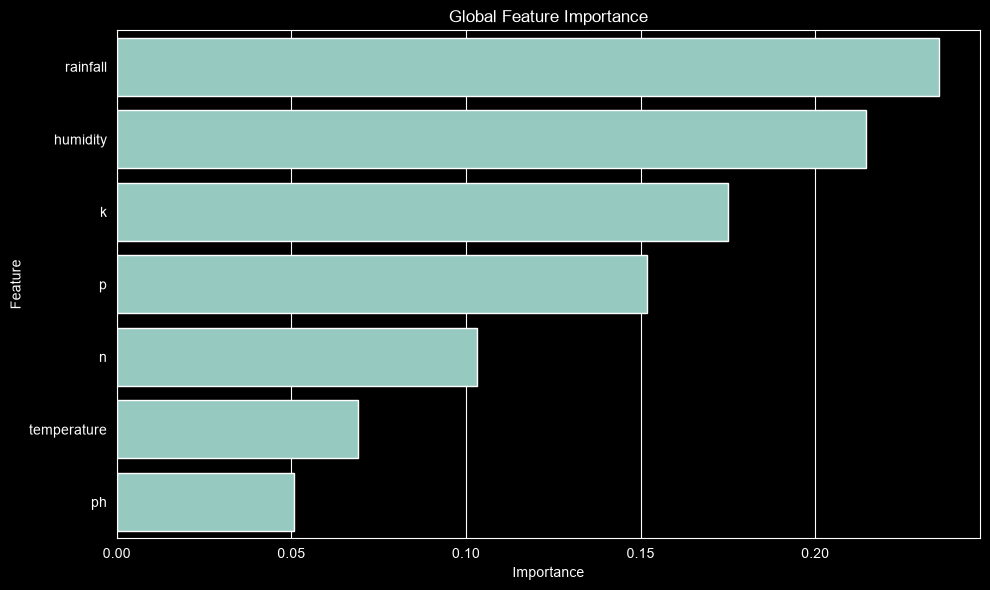

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)
plt.title("Global Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

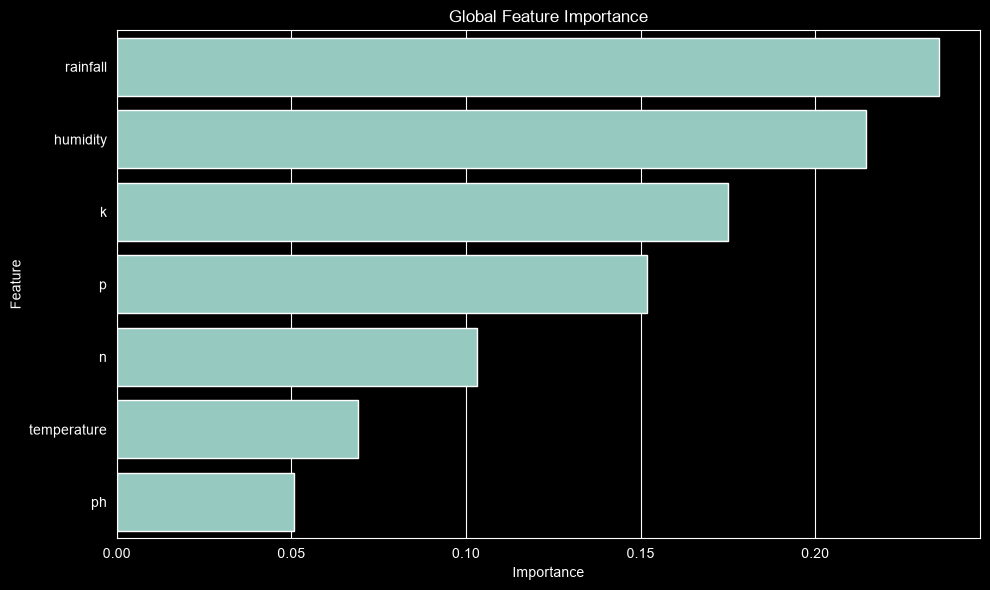

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)
plt.title("Global Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/figures/global_feature_importance.png", dpi=300)
plt.show()

Global feature importance shows which variables the tree-based model used most often to make crop classification decisions. Higher importance means the feature contributed more to reducing prediction uncertainty across the ensemble.

In [35]:
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [36]:
permutation_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df

,feature,importance_mean,importance_std
0,humidity,0.263736,0.014165
1,rainfall,0.252776,0.013501
2,n,0.220363,0.014704
3,k,0.216426,0.013456
4,p,0.186457,0.019633
5,ph,0.010828,0.003897
6,temperature,0.009602,0.003465


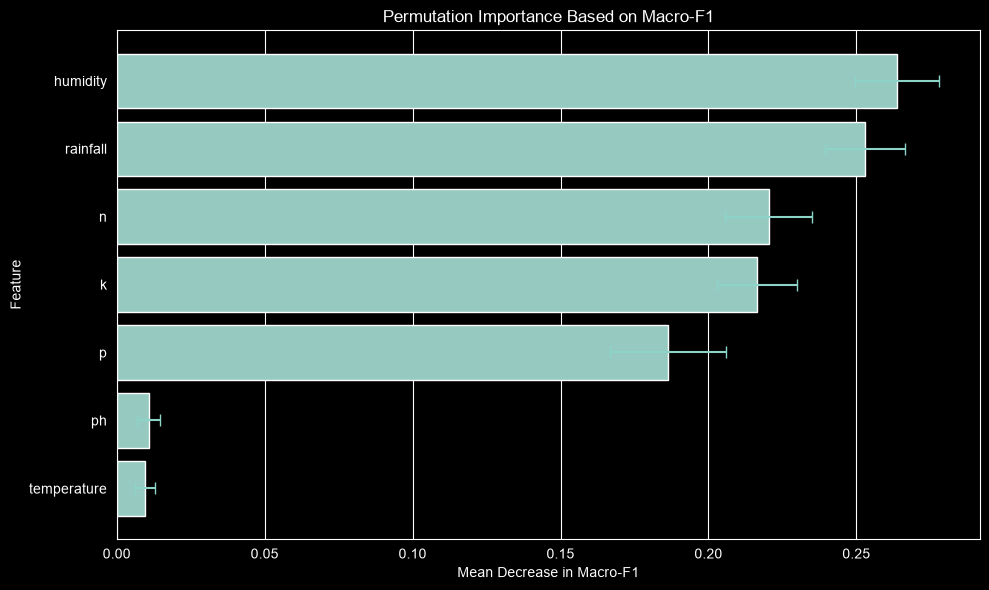

In [37]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=permutation_importance_df,
    x="importance_mean",
    y="feature"
)

ax.errorbar(
    x=permutation_importance_df["importance_mean"],
    y=range(len(permutation_importance_df)),
    xerr=permutation_importance_df["importance_std"],
    fmt="none",
    capsize=4
)

plt.title("Permutation Importance Based on Macro-F1")
plt.xlabel("Mean Decrease in Macro-F1")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

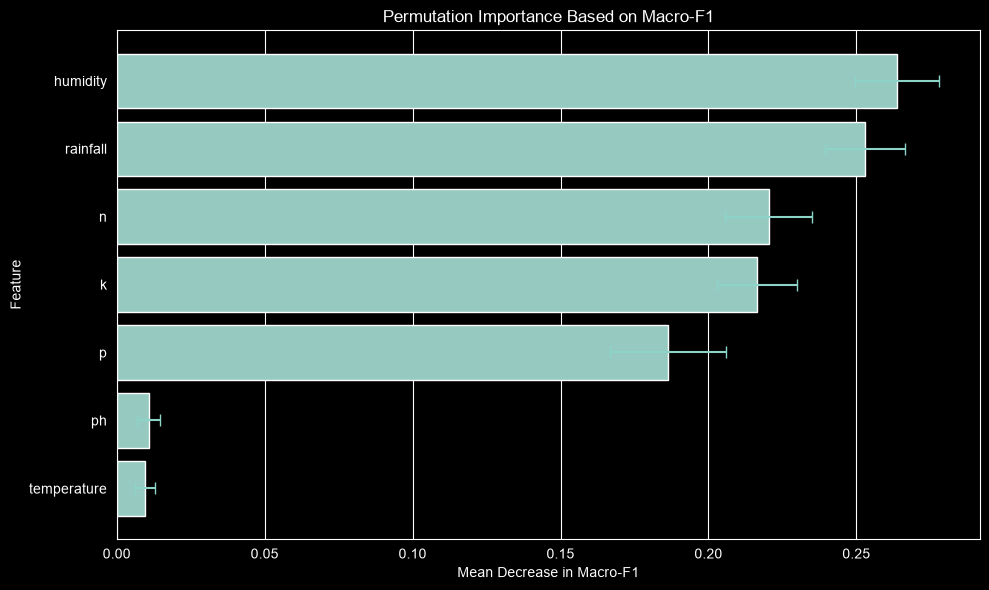

In [38]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=permutation_importance_df,
    x="importance_mean",
    y="feature"
)


ax.errorbar(
    x=permutation_importance_df["importance_mean"],
    y=range(len(permutation_importance_df)),
    xerr=permutation_importance_df["importance_std"],
    fmt="none",
    capsize=4
)
plt.title("Permutation Importance Based on Macro-F1")
plt.xlabel("Mean Decrease in Macro-F1")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/figures/permutation_importance.png", dpi=300)
plt.show()

Permutation importance measures how much model performance drops when a feature is randomly shuffled. This provides a model-agnostic view of feature relevance. Features that cause the largest decrease in macro-F1 are the most important for prediction.

In [39]:
# Compare importance methods

importance_comparison = feature_importance_df.merge(
    permutation_importance_df,
    on="feature",
    how="inner"
)

importance_comparison

,feature,importance,importance_mean,importance_std
0,rainfall,0.235417,0.252776,0.013501
1,humidity,0.214631,0.263736,0.014165
2,k,0.174967,0.216426,0.013456
3,p,0.151864,0.186457,0.019633
4,n,0.103185,0.220363,0.014704
5,temperature,0.069130,0.009602,0.003465
6,ph,0.050805,0.010828,0.003897


In [40]:
importance_comparison.to_csv(
    "../reports/figures/feature_importance_comparison.csv",
    index=False
)

Comparing built-in feature importance with permutation importance helps validate whether the same features consistently appear important across different explanation methods.

In [41]:
# Create a local prediction explanation

crop_profiles = df.groupby(target_col)[feature_names].mean()

crop_profiles

,n,p,k,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


In [42]:
# Creating sample input

sample_input = {
    "n": 90,
    "p": 42,
    "k": 43,
    "temperature": 20.8,
    "humidity": 82.0,
    "ph": 6.5,
    "rainfall": 202.9
}

In [43]:
sample_df = pd.DataFrame([sample_input])

prediction = model.predict(sample_df)[0]
probabilities = model.predict_proba(sample_df)[0]

prediction

'rice'

In [44]:
class_probabilities = (pd.DataFrame({
    "crop": model.classes_,
    "probability": probabilities
})
                       .sort_values("probability", ascending=False))

class_probabilities.head(3)

,crop,probability
20,rice,0.985
8,jute,0.015
2,blackgram,0.000


In [46]:
predicted_crop_profile = crop_profiles.loc[prediction]

comparison_df = pd.DataFrame({
    "feature": feature_names,
    "input_value": [sample_input[f] for f in feature_names],
    "predicted_crop_average": predicted_crop_profile.values
})

comparison_df["difference"] = (
    comparison_df["input_value"] - comparison_df["predicted_crop_average"]
)

comparison_df["absolute_difference"] = comparison_df["difference"].abs()

comparison_df.sort_values("absolute_difference")

,feature,input_value,predicted_crop_average,difference,absolute_difference
5,ph,6.5,6.425471,0.074529,0.074529
4,humidity,82.0,82.272822,-0.272822,0.272822
3,temperature,20.8,23.689332,-2.889332,2.889332
2,k,43.0,39.870000,3.130000,3.130000
1,p,42.0,47.580000,-5.580000,5.580000
0,n,90.0,79.890000,10.110000,10.110000
6,rainfall,202.9,236.181114,-33.281114,33.281114


This comparison explains how close the user-provided soil and climate values are to the average profile of the predicted crop. Features with smaller differences are more consistent with the predicted crop's historical profile in the dataset.

In [47]:
def explain_prediction(input_data, model, crop_profiles,
                       feature_names, top_n=3):
    input_df = pd.DataFrame([input_data])[feature_names]

    prediction = model.predict(input_df)[0]
    probabilities = model.predict_proba(input_df)[0]

    probability_df = (
        pd.DataFrame({
            "crop": model.classes_,
            "probability": probabilities
        })
        .sort_values("probability", ascending=False)
        .reset_index(drop=True)
    )

    predicted_profile = crop_profiles.loc[prediction]

    comparison_df = pd.DataFrame({
        "feature": feature_names,
        "input_value": [input_data[f] for f in feature_names],
        "predicted_crop_average": predicted_profile.values
    })

    comparison_df["difference"] = (
        comparison_df["input_value"] - comparison_df["predicted_crop_average"] - comparison_df["predicted_crop_average"]
    )

    comparison_df["absolute_difference"] = comparison_df["difference"].abs()

    closest_features = (
        comparison_df
        .sort_values("absolute_difference")
        .head(top_n)
    )

    explanation = {
        "prediction": prediction,
        "confidence": float(probability_df.loc[0, "probability"]),
        "top_recommendations": probability_df.head(top_n).to_dict(orient="records"),
        "closest_matching_features": closest_features.to_dict(orient="records")
    }

    return explanation

In [48]:
explanation = explain_prediction(
    sample_input,
    model,
    crop_profiles,
    feature_names
)

explanation

{'prediction': 'rice',
 'confidence': 0.985,
 'top_recommendations': [{'crop': 'rice', 'probability': 0.985},
  {'crop': 'jute', 'probability': 0.015},
  {'crop': 'blackgram', 'probability': 0.0}],
 'closest_matching_features': [{'feature': 'ph',
   'input_value': 6.5,
   'predicted_crop_average': 6.425470922140001,
   'difference': -6.350941844280001,
   'absolute_difference': 6.350941844280001},
  {'feature': 'temperature',
   'input_value': 20.8,
   'predicted_crop_average': 23.6893322105,
   'difference': -26.578664421000003,
   'absolute_difference': 26.578664421000003},
  {'feature': 'k',
   'input_value': 43.0,
   'predicted_crop_average': 39.87,
   'difference': -36.739999999999995,
   'absolute_difference': 36.739999999999995}]}

In [49]:
def format_explanation(explanation):
    prediction = explanation["prediction"]
    confidence = explanation["confidence"]
    closest_features = explanation["closest_matching_features"]

    text = f"The recommended crop is {prediction} with confidence of {confidence:.1%}.\n\n"
    text += "The input values most closely match the predicted crop profile for:\n"

    for item in closest_features:
        feature = item["feature"]
        input_value = item["input_value"]
        crop_average = item["predicted_crop_average"]

        text += (
            f"- {feature}: input value {input_value:.2f}, "
            f"typical {prediction} average {crop_average:.2f}\n"
        )

    return text

In [50]:
print(format_explanation(explanation))

The recommended crop is rice with confidence of 98.5%.

The input values most closely match the predicted crop profile for:
- ph: input value 6.50, typical rice average 6.43
- temperature: input value 20.80, typical rice average 23.69
- k: input value 43.00, typical rice average 39.87



In [51]:
explainer = shap.TreeExplainer(final_model)

In [52]:
scaler = model.named_steps["scaler"]

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

In [55]:
shap_values = explainer.shap_values(X_test_scaled_df)

shap_values

array([[[ 3.47088294e-03, -1.41757547e-02, -2.97039844e-03, ...,
          3.61529546e-02, -1.17586224e-02, -3.26070059e-02],
        [-3.98138819e-02, -1.79269971e-02, -2.19004268e-02, ...,
          4.68229429e-02, -5.57702255e-03,  2.18758193e-02],
        [-4.02965992e-02, -1.08759532e-02,  4.88064397e-03, ...,
         -1.97129995e-01, -1.10787512e-02, -1.59445283e-02],
        ...,
        [ 1.40035996e-02, -2.80984738e-03, -1.39551274e-02, ...,
          1.44110578e-02, -4.59312234e-03,  1.84228555e-03],
        [-2.55020071e-03, -4.24727004e-03,  4.93478665e-03, ...,
         -1.70168560e-02, -1.17651313e-03, -1.41378650e-03],
        [ 1.43188580e-02,  7.32726879e-03, -8.06195541e-03, ...,
          3.56746757e-02, -1.20883357e-02, -2.12346072e-02]],

       [[-4.52696475e-03,  1.66244896e-01, -1.60723678e-02, ...,
         -4.19838766e-02,  2.55956090e-02,  2.98324786e-02],
        [-2.11086270e-02,  3.59977819e-01,  1.42413711e-02, ...,
         -4.21804525e-02, -2.83328542e

In [54]:
type(shap_values)

numpy.ndarray

Selected crop class: apple
Selected SHAP shape: (440, 7)
X_test shape: (440, 7)


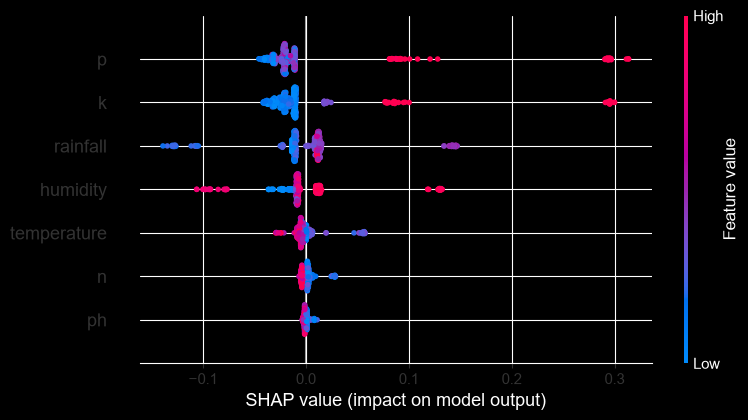

In [62]:
class_index = 0
selected_class = model.classes_[class_index]

if isinstance(shap_values, list):
    shap_values_for_class = shap_values[class_index]
else:
    shap_values_for_class = shap_values[:, :, class_index]

print("Selected crop class:", selected_class)
print("Selected SHAP shape:", shap_values_for_class.shape)
print("X_test shape:", X_test_scaled_df.shape)

shap.summary_plot(
    shap_values_for_class,
    X_test_scaled_df,
    feature_names=X_test_scaled_df.columns,
    show=True
)

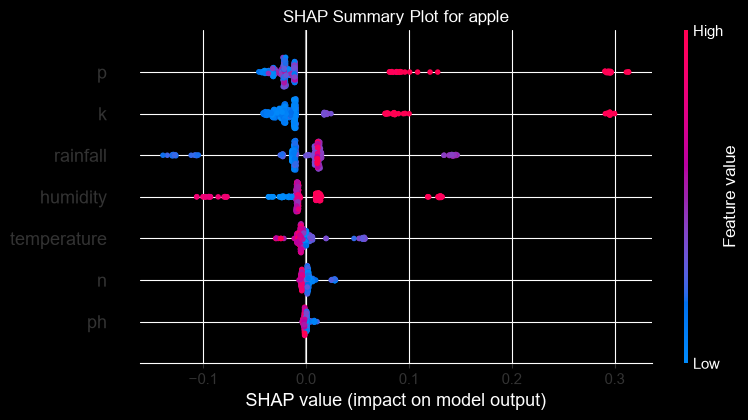

In [63]:
class_index = 0
selected_class = model.classes_[class_index]

if isinstance(shap_values, list):
    shap_values_for_class = shap_values[class_index]
else:
    shap_values_for_class = shap_values[:, :, class_index]

shap.summary_plot(
    shap_values_for_class,
    X_test_scaled_df,
    feature_names=X_test_scaled_df.columns,
    show=False
)

plt.title(f"SHAP Summary Plot for {selected_class}")
plt.tight_layout()
plt.savefig(
    f"../reports/figures/shap_summary_{selected_class}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

This SHAP summary plot explains the model's predictions for the selected crop class. Features farther from zero have stronger influence on the model output. Positive SHAP values push the model toward predicting this crop class, while negative SHAP values push the model away from it.

In [64]:
selected_crops = ["rice", "maize", "cotton", "banana", "coffee"]

In [65]:
for crop in selected_crops:
    class_index = list(model.classes_).index(crop)

    if isinstance(shap_values, list):
        shap_values_for_class = shap_values[class_index]
    else:
        shap_values_for_class = shap_values[:, :, class_index]

    shap.summary_plot(
        shap_values_for_class,
        X_test_scaled_df,
        feature_names=X_test_scaled_df.columns,
        show=False
    )

    plt.title(f"SHAP Summary Plot for {crop}")
    plt.tight_layout()
    plt.savefig(
        f"../reports/figures/shap_summary_{crop}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

## SHAP Interpretation

SHAP was used to explain the trained tree-based model at the crop-class level. Because this is a multi-class classification problem, SHAP values are generated separately for each crop class.

For a selected crop, positive SHAP values indicate that a feature pushes the model toward predicting that crop, while negative SHAP values push the model away from that crop.

The color scale represents the original feature value. Red points indicate high feature values, while blue points indicate low feature values. This helps show whether high or low values of a feature support the prediction of a particular crop.

The SHAP plot confirms that the model uses multiple soil and climate variables rather than relying on a single predictor. Features such as phosphorus, potassium, rainfall, humidity, and temperature show visible influence on model output depending on the selected crop class.